# ECE1513 practical session 10


### Learning outcomes:
    1. Create torch dataset
    2. Init data loaders
    3. Build a fully connected network using Pytorch
    4. Train, evaluate, and test the model
    5. Tune some hyperparameters



#### Import required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms


#### Loading the MNIST Dataset


The MNIST dataset is a famous dataset in machine learning and computer vision, consisting of 28x28 grayscale images of handwritten digits (0 through 9). Each image is associated with a label indicating the digit it represents.

Here's an introduction to the MNIST dataset along with Python code to load it using PyTorch and visualize some sample images:

In [2]:
# Define a transformation to normalize the data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Load the MNIST training and test datasets
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)



100%|██████████| 9.91M/9.91M [00:00<00:00, 15.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 416kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.11MB/s]


In [3]:
# Create data loaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False)


In [4]:
for batch_idx,(data , labels) in enumerate(train_loader):
  print(f'input {batch_idx}: {data.shape}, target: {labels.shape}')
  break



input 0: torch.Size([16, 1, 28, 28]), target: torch.Size([16])


#### Visualize random sample from training loader

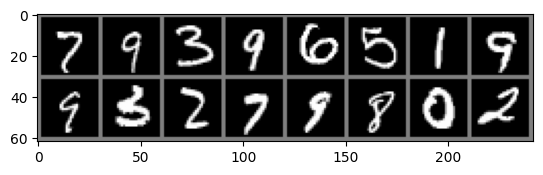


     7     9     3     9     6     5     1     9     9     3     2     7     9     8     0     2


In [5]:
# Function to show images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

images, labels = next(iter(train_loader))

# Show images
imshow(torchvision.utils.make_grid(images))
# Print labels
print('\n',' '.join('%5s' % labels[j].item() for j in range(16)))

#### Building the network

- Class Name: `NeuralNetwork`
- Inherits from: `torch.nn.Module`
- Initialization:
  - Creates a fully connected layer (`fc1`) with input size of 28*28 and output size of 128 neurons.
  - Applies ReLU activation function (`relu`).
  - Creates another fully connected layer (`fc2`) with input size of 128 and output size of 64 neurons.
  - Creates the final fully connected layer (`fc3`) with input size of 64 and output size of 10 neurons.
- Forward Method:
  - Reshapes the input tensor `x` into a 2D tensor with size (-1, 28 * 28), where -1 indicates batch size.
  - Applies ReLU activation to the output of the first fully connected layer (`fc1`).
  - Applies ReLU activation to the output of the second fully connected layer (`fc2`).
  - Computes the output of the final fully connected layer (`fc3`).
- Returns: The output tensor representing the predicted class scores.


In [6]:
torch.manual_seed(1)

class NeuralNetwork(torch.nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = torch.nn.Linear(28 * 28, 128)
        self.fc2 = torch.nn.Linear(128, 64)
        self.fc3 = torch.nn.Linear(64, 10)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


#### Initializing the network, choosing a loss function and optimizer

- Object Creation:
  - Creates an instance of the `NeuralNetwork` class and assigns it to the variable `net`.
- Loss Function:
  - Defines the loss function as Cross Entropy Loss (`torch.nn.CrossEntropyLoss()`), which is commonly used for multi-class classification tasks.
- Optimizer:
  - Uses Stochastic Gradient Descent (SGD) optimizer (`torch.optim.SGD`) to optimize the parameters of the neural network.
  - Specifies the parameters to be optimized using `net.parameters()`.
  - Sets the learning rate (`lr`) to 0.01 for controlling the step size during optimization.


In [7]:
net = NeuralNetwork()
inputs, targets = next(iter(train_loader))

print(inputs.shape)
print(net(inputs).shape,'\n')

output_0 = net(inputs)[0]
print('output 0: ', output_0,'\n')

pred_0 = torch.max(output_0.detach().reshape(1,-1),1)
print('prediction 0: ', pred_0[1])

torch.Size([16, 1, 28, 28])
torch.Size([16, 10]) 

output 0:  tensor([-0.1115,  0.2108, -0.1083,  0.2256, -0.1195, -0.1373, -0.1022, -0.0299,
         0.0787, -0.0256], grad_fn=<SelectBackward0>) 

prediction 0:  tensor([3])


In [8]:
# initialize loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.01)

#### Training the network

- Training Loop:
  - `for epoch in range(20):`: Loops over the dataset for a specified number of epochs (20 in this case).
  - `running_loss = 0.0`: Initializes the running loss variable to zero at the start of each epoch.
  - `for i, data in enumerate(train_loader, 0):`: Loops over the batches of data in the training dataset using `enumerate(train_loader, 0)`.
    - `inputs, labels = data`: Unpacks the input data and labels from the batch.
    - `optimizer.zero_grad()`: Clears the gradients of all optimized parameters before backward pass.
    - `outputs = net(inputs)`: Performs forward pass to get the predicted outputs from the neural network.
    - `loss = criterion(outputs, labels)`: Calculates the loss between the predicted outputs and the ground truth labels using the specified criterion (CrossEntropyLoss).
    - `loss.backward()`: Backpropagates the loss gradient through the network's parameters.
    - `optimizer.step()`: Updates the parameters of the model using the gradients computed in the backward pass.
    - `running_loss += loss.item()`: Accumulates the loss for the current batch.
  - `print('[%d] loss: %.3f' % (epoch + 1, running_loss / len(train_loader)))`: Prints the average loss for the epoch, calculated by dividing the total accumulated loss by the number of batches in the training dataset.
  - `running_loss = 0.0`: Resets the running loss variable to zero for the next epoch.
- After Training:
  - Prints "Finished Training" after completing all epochs.


In [9]:
from sklearn.metrics import f1_score, accuracy_score

# Train the neural network
for epoch in range(20):  # Loop over the dataset multiple times
    running_loss = 0.0
    correct = 0
    total = 0
    all_predicted = []
    all_labels = []

    for i, (inputs, labels) in enumerate(train_loader, 0):
        optimizer.zero_grad()  # Zero the parameter gradients

        # Forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Collect predictions and labels for F1 score calculation
        all_predicted.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        running_loss += loss.item()

    # Calculate F1 score
    f1 = f1_score(all_labels, all_predicted, average='weighted')

    # Print the loss, accuracy, and F1 score after each epoch
    print('[%d] loss: %.3f | accuracy: %.2f%% | F1 score: %.4f' % (epoch + 1, running_loss / len(train_loader), 100 * correct / total, f1))
    running_loss = 0.0

print('Finished Training')


[1] loss: 0.537 | accuracy: 84.14% | F1 score: 0.8407
[2] loss: 0.256 | accuracy: 92.39% | F1 score: 0.9238
[3] loss: 0.189 | accuracy: 94.29% | F1 score: 0.9428
[4] loss: 0.149 | accuracy: 95.53% | F1 score: 0.9553
[5] loss: 0.124 | accuracy: 96.22% | F1 score: 0.9621
[6] loss: 0.107 | accuracy: 96.77% | F1 score: 0.9676
[7] loss: 0.093 | accuracy: 97.20% | F1 score: 0.9720
[8] loss: 0.083 | accuracy: 97.48% | F1 score: 0.9748
[9] loss: 0.074 | accuracy: 97.69% | F1 score: 0.9769
[10] loss: 0.066 | accuracy: 97.95% | F1 score: 0.9795
[11] loss: 0.061 | accuracy: 98.10% | F1 score: 0.9810
[12] loss: 0.055 | accuracy: 98.24% | F1 score: 0.9824
[13] loss: 0.051 | accuracy: 98.43% | F1 score: 0.9843
[14] loss: 0.046 | accuracy: 98.59% | F1 score: 0.9859
[15] loss: 0.043 | accuracy: 98.67% | F1 score: 0.9866
[16] loss: 0.039 | accuracy: 98.80% | F1 score: 0.9879
[17] loss: 0.037 | accuracy: 98.89% | F1 score: 0.9889
[18] loss: 0.034 | accuracy: 98.95% | F1 score: 0.9895
[19] loss: 0.032 | 

#### Testing the model

- Testing Loop:
  - `correct = 0`: Initializes a variable to count the number of correctly predicted labels.
  - `total = 0`: Initializes a variable to count the total number of test samples.
  - `with torch.no_grad():`: Context manager to disable gradient computation, since we're only evaluating the model, not training it.
    - `for data in test_loader:`: Loops over the batches of data in the test dataset.
      - `images, labels = data`: Unpacks the input images and labels from the test batch.
      - `outputs = net(images)`: Performs forward pass to get the predicted outputs from the neural network.
      - `_, predicted = torch.max(outputs.data, 1)`: Computes the predicted labels by selecting the index with the maximum value from the output tensor.
      - `total += labels.size(0)`: Increments the total count by the number of labels in the batch.
      - `correct += (predicted == labels).sum().item()`: Increments the correct count by the number of correct predictions in the batch.
  - `print('Accuracy on the 10000 test images: %.2f%%' % (100 * correct / total))`: Calculates and prints the accuracy of the model on the test dataset as a percentage.


In [10]:
# Test the neural network
correct = 0
total = 0
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Testing accuracy is: %.2f%%' % (100 * correct / total))

Testing accuracy is: 97.35%


#### Model Validation and Hyper Parameter Tuning

Model validation and hyperparameter tuning are crucial steps in the machine learning workflow to ensure that the model generalizes well to unseen data and performs optimally.

#### Model Validation
Model validation involves evaluating the performance of the model on a separate validation dataset that was not used during training. This helps in assessing how well the model is likely to perform on new, unseen data. Common techniques for model validation include:
- **Holdout Validation**: Splitting the dataset into training and validation sets.
- **Cross-Validation**: Dividing the dataset into multiple folds and training the model on different combinations of folds.


#### Hyperparameter Tuning
Hyperparameters are parameters that are not learned during training but are set before the training process begins. Tuning these hyperparameters is essential to improve the performance. Important hyperparameters in deep learning include:
- **Learning Rate**: Controls the step size during gradient descent optimization.
- **Batch Size**: Number of training samples used in one forward/backward pass.
- **Number of Epochs**: Number of times the entire training dataset is passed through the model.
- **Optimizer**: Algorithm used to update the weights (e.g., SGD, Adam).
- **Dropout Rate**: Fraction of neurons to drop during training to prevent overfitting.
- **Number of Layers and Units**: Architecture of the neural network, including the number of layers and units per layer.

#### Example: Tuning Learning Rate
In this example, we will focus on tuning the learning rate, which is a critical hyperparameter that controls how quickly the model updates its weights. A learning rate that is too high can cause the model to converge too quickly to a suboptimal solution, while a learning rate that is too low can result in a long training process and potentially getting stuck in local minima.

In [11]:
# Define a transformation to normalize the data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Load the MNIST training and test datasets
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])


In [12]:
# Create data loaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False)


In [13]:
def train_model(model, optimizer):
  criterion = torch.nn.CrossEntropyLoss()
  train_loss = []
  val_loss = []
  for epoch in range(10):  # Loop over the dataset multiple times
      running_loss = 0.0
      running_acc = 0.0
      running_val_loss = 0.0
      running_val_acc = 0.0
      correct = 0
      total = 0
      model.train()
      for data in train_loader:
        inputs, labels = data
        optimizer.zero_grad()  # Clean up the gradients parameters

        # Forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

      running_acc = correct / total
      running_loss = running_loss / len(train_loader)

      ## model validation
      model.eval()
      with torch.no_grad():
        for data in val_loader:
          inputs, labels = data
          outputs = net(inputs)
          loss = criterion(outputs, labels)
          running_val_loss += loss.item()
          # Calculate training accuracy
          _, predicted = torch.max(outputs.data, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

      running_val_acc = correct / total
      running_val_loss = running_val_loss / len(val_loader)
      train_loss.append(running_loss)
      val_loss.append(running_val_loss)
      # Print the loss, accuracy, and F1 score after each epoch
      print('[%d] loss: %.3f |  Val loss: %.3f | acc: %.2f  | Val acc: %.2f | ' % (epoch + 1, running_loss, running_val_loss, running_acc, running_val_acc))
  return train_loss, val_loss, model

In [14]:
def test_model(net):
  correct = 0
  total = 0
  with torch.no_grad():
      for data in test_loader:
          images, labels = data
          outputs = net(images)
          _, predicted = torch.max(outputs.data, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()
  print('Testing accuracy is: %.2f%%' % (100 * correct / total))

[1] loss: 2.344 |  Val loss: 2.315 | acc: 0.10  | Val acc: 0.10 | 
[2] loss: 2.315 |  Val loss: 2.327 | acc: 0.10  | Val acc: 0.10 | 
[3] loss: 2.312 |  Val loss: 2.315 | acc: 0.10  | Val acc: 0.10 | 
[4] loss: 2.313 |  Val loss: 2.320 | acc: 0.10  | Val acc: 0.10 | 
[5] loss: 2.313 |  Val loss: 2.307 | acc: 0.10  | Val acc: 0.11 | 
[6] loss: 2.313 |  Val loss: 2.308 | acc: 0.10  | Val acc: 0.10 | 
[7] loss: 2.312 |  Val loss: 2.317 | acc: 0.11  | Val acc: 0.10 | 
[8] loss: 2.313 |  Val loss: 2.310 | acc: 0.10  | Val acc: 0.10 | 
[9] loss: 2.313 |  Val loss: 2.324 | acc: 0.10  | Val acc: 0.10 | 
[10] loss: 2.313 |  Val loss: 2.309 | acc: 0.10  | Val acc: 0.10 | 
Testing accuracy is: 9.80%


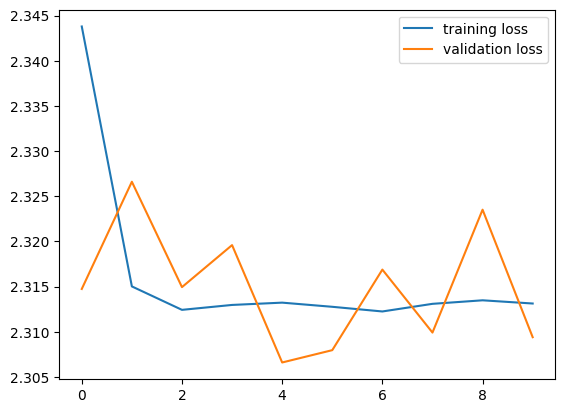

In [15]:
# Let's experiment a high learning rate

net = NeuralNetwork()
optimizer = torch.optim.SGD(net.parameters(), lr=0.8)
train_loss, val_loss, model = train_model(net, optimizer)
test_model(model)
plt.plot(train_loss, label='training loss')
plt.plot(val_loss, label='validation loss')
plt.legend()
plt.show()

[1] loss: 2.313 |  Val loss: 2.310 | acc: 0.08  | Val acc: 0.08 | 
[2] loss: 2.307 |  Val loss: 2.305 | acc: 0.09  | Val acc: 0.09 | 
[3] loss: 2.302 |  Val loss: 2.299 | acc: 0.09  | Val acc: 0.09 | 
[4] loss: 2.297 |  Val loss: 2.294 | acc: 0.10  | Val acc: 0.10 | 
[5] loss: 2.291 |  Val loss: 2.289 | acc: 0.11  | Val acc: 0.11 | 
[6] loss: 2.286 |  Val loss: 2.284 | acc: 0.13  | Val acc: 0.13 | 
[7] loss: 2.281 |  Val loss: 2.278 | acc: 0.15  | Val acc: 0.15 | 
[8] loss: 2.275 |  Val loss: 2.273 | acc: 0.16  | Val acc: 0.16 | 
[9] loss: 2.270 |  Val loss: 2.268 | acc: 0.18  | Val acc: 0.18 | 
[10] loss: 2.265 |  Val loss: 2.262 | acc: 0.20  | Val acc: 0.20 | 
Testing accuracy is: 20.88%


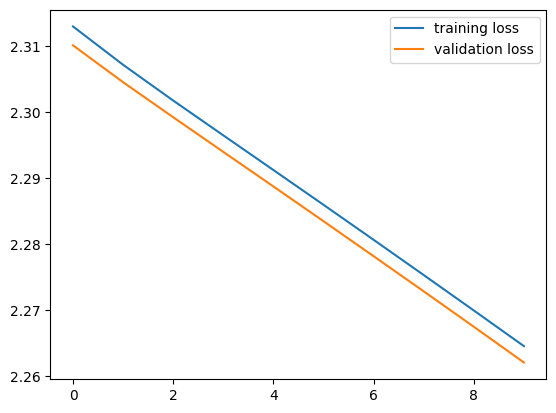

In [16]:
# Now a very small learning rate

net = NeuralNetwork()
optimizer = torch.optim.SGD(net.parameters(), lr=0.00001)
train_loss, val_loss, model = train_model(net, optimizer)
test_model(model)
plt.plot(train_loss, label='training loss')
plt.plot(val_loss, label='validation loss')
plt.legend()
plt.show()

[1] loss: 0.577 |  Val loss: 0.305 | acc: 0.83  | Val acc: 0.85 | 
[2] loss: 0.278 |  Val loss: 0.234 | acc: 0.92  | Val acc: 0.92 | 
[3] loss: 0.211 |  Val loss: 0.179 | acc: 0.94  | Val acc: 0.94 | 
[4] loss: 0.171 |  Val loss: 0.152 | acc: 0.95  | Val acc: 0.95 | 
[5] loss: 0.143 |  Val loss: 0.141 | acc: 0.96  | Val acc: 0.96 | 
[6] loss: 0.123 |  Val loss: 0.127 | acc: 0.96  | Val acc: 0.96 | 
[7] loss: 0.108 |  Val loss: 0.115 | acc: 0.97  | Val acc: 0.97 | 
[8] loss: 0.095 |  Val loss: 0.106 | acc: 0.97  | Val acc: 0.97 | 
[9] loss: 0.085 |  Val loss: 0.115 | acc: 0.98  | Val acc: 0.97 | 
[10] loss: 0.077 |  Val loss: 0.095 | acc: 0.98  | Val acc: 0.98 | 
Testing accuracy is: 97.15%


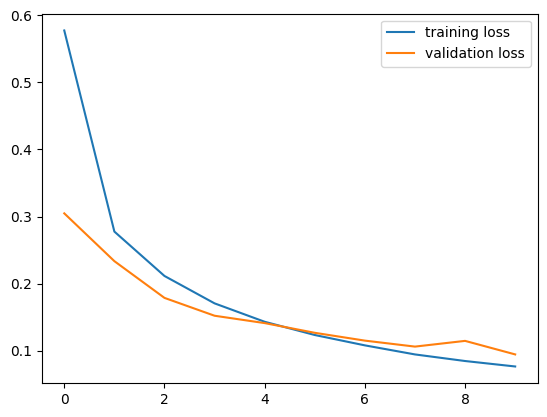

In [17]:
# Now a not-too-big-not-too-small learning rate

net = NeuralNetwork()
optimizer = torch.optim.SGD(net.parameters(), lr=0.01)
train_loss, val_loss, model = train_model(net, optimizer)
test_model(model)
plt.plot(train_loss, label='training loss')
plt.plot(val_loss, label='validation loss')
plt.legend()
plt.show()

#### Example: Pytorch [Optimizers](https://pytorch.org/docs/stable/optim.html)

[1] loss: 0.360 |  Val loss: 0.220 | acc: 0.89  | Val acc: 0.90 | 
[2] loss: 0.182 |  Val loss: 0.150 | acc: 0.94  | Val acc: 0.95 | 
[3] loss: 0.140 |  Val loss: 0.135 | acc: 0.96  | Val acc: 0.96 | 
[4] loss: 0.118 |  Val loss: 0.130 | acc: 0.96  | Val acc: 0.96 | 
[5] loss: 0.104 |  Val loss: 0.113 | acc: 0.97  | Val acc: 0.97 | 
[6] loss: 0.094 |  Val loss: 0.160 | acc: 0.97  | Val acc: 0.97 | 
[7] loss: 0.087 |  Val loss: 0.128 | acc: 0.97  | Val acc: 0.97 | 
[8] loss: 0.080 |  Val loss: 0.120 | acc: 0.97  | Val acc: 0.97 | 
[9] loss: 0.073 |  Val loss: 0.111 | acc: 0.98  | Val acc: 0.98 | 
[10] loss: 0.068 |  Val loss: 0.127 | acc: 0.98  | Val acc: 0.98 | 
Testing accuracy is: 96.32%


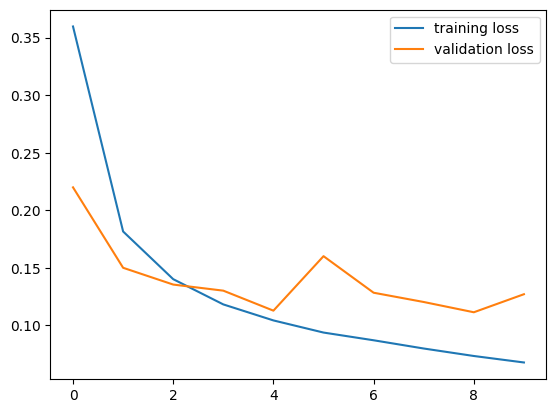

In [18]:
# Adam - Adaptive Moment Estimation - optimizer

net = NeuralNetwork()
optimizer = torch.optim.Adam(net.parameters())
train_loss, val_loss, model = train_model(net, optimizer)
test_model(model)
plt.plot(train_loss, label='training loss')
plt.plot(val_loss, label='validation loss')
plt.legend()
plt.show()

#### Example: The model architecture

[1] loss: 0.827 |  Val loss: 0.544 | acc: 0.74  | Val acc: 0.76 | 
[2] loss: 0.507 |  Val loss: 0.496 | acc: 0.85  | Val acc: 0.85 | 
[3] loss: 0.450 |  Val loss: 0.423 | acc: 0.86  | Val acc: 0.87 | 
[4] loss: 0.421 |  Val loss: 0.428 | acc: 0.87  | Val acc: 0.87 | 
[5] loss: 0.407 |  Val loss: 0.422 | acc: 0.88  | Val acc: 0.88 | 
[6] loss: 0.399 |  Val loss: 0.400 | acc: 0.88  | Val acc: 0.88 | 
[7] loss: 0.390 |  Val loss: 0.381 | acc: 0.88  | Val acc: 0.89 | 
[8] loss: 0.388 |  Val loss: 0.379 | acc: 0.89  | Val acc: 0.89 | 
[9] loss: 0.383 |  Val loss: 0.388 | acc: 0.89  | Val acc: 0.89 | 
[10] loss: 0.380 |  Val loss: 0.395 | acc: 0.89  | Val acc: 0.89 | 
Testing accuracy is: 88.19%


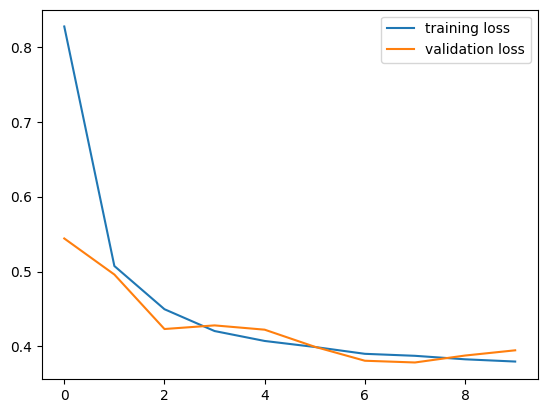

In [19]:
torch.manual_seed(1)

class NeuralNetwork(torch.nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = torch.nn.Linear(28 * 28, 10)
        self.fc2 = torch.nn.Linear(10, 10)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

net = NeuralNetwork()
optimizer = torch.optim.Adam(net.parameters())
train_loss, val_loss, model = train_model(net, optimizer)
test_model(model)
plt.plot(train_loss, label='training loss')
plt.plot(val_loss, label='validation loss')
plt.legend()
plt.show()

[1] loss: 0.296 |  Val loss: 0.175 | acc: 0.91  | Val acc: 0.92 | 
[2] loss: 0.152 |  Val loss: 0.161 | acc: 0.95  | Val acc: 0.95 | 
[3] loss: 0.117 |  Val loss: 0.164 | acc: 0.96  | Val acc: 0.96 | 
[4] loss: 0.100 |  Val loss: 0.150 | acc: 0.97  | Val acc: 0.97 | 
[5] loss: 0.087 |  Val loss: 0.131 | acc: 0.97  | Val acc: 0.97 | 
[6] loss: 0.080 |  Val loss: 0.119 | acc: 0.97  | Val acc: 0.97 | 
[7] loss: 0.072 |  Val loss: 0.127 | acc: 0.98  | Val acc: 0.98 | 
[8] loss: 0.063 |  Val loss: 0.125 | acc: 0.98  | Val acc: 0.98 | 
[9] loss: 0.061 |  Val loss: 0.132 | acc: 0.98  | Val acc: 0.98 | 
[10] loss: 0.055 |  Val loss: 0.129 | acc: 0.98  | Val acc: 0.98 | 
Testing accuracy is: 97.47%


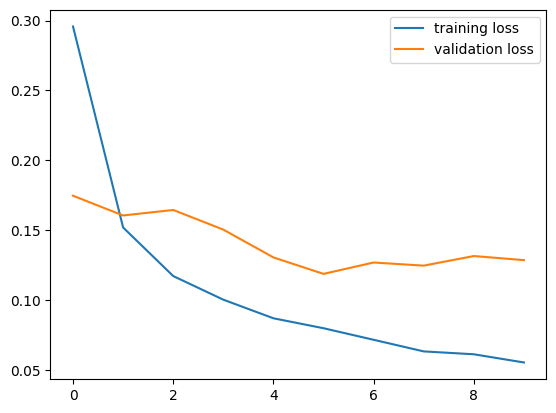

In [20]:
torch.manual_seed(1)

class NeuralNetwork(torch.nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = torch.nn.Linear(28 * 28, 1000)
        self.fc2 = torch.nn.Linear(1000, 10)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

net = NeuralNetwork()
optimizer = torch.optim.Adam(net.parameters())
train_loss, val_loss, model = train_model(net, optimizer)
test_model(model)
plt.plot(train_loss, label='training loss')
plt.plot(val_loss, label='validation loss')
plt.legend()
plt.show()

[1] loss: 0.436 |  Val loss: 0.368 | acc: 0.87  | Val acc: 0.88 | 
[2] loss: 0.369 |  Val loss: 0.327 | acc: 0.89  | Val acc: 0.89 | 
[3] loss: 0.352 |  Val loss: 0.332 | acc: 0.90  | Val acc: 0.90 | 
[4] loss: 0.344 |  Val loss: 0.335 | acc: 0.90  | Val acc: 0.90 | 
[5] loss: 0.333 |  Val loss: 0.341 | acc: 0.90  | Val acc: 0.90 | 
[6] loss: 0.328 |  Val loss: 0.322 | acc: 0.90  | Val acc: 0.91 | 
[7] loss: 0.321 |  Val loss: 0.331 | acc: 0.91  | Val acc: 0.91 | 
[8] loss: 0.317 |  Val loss: 0.353 | acc: 0.91  | Val acc: 0.91 | 
[9] loss: 0.315 |  Val loss: 0.350 | acc: 0.91  | Val acc: 0.91 | 
[10] loss: 0.310 |  Val loss: 0.320 | acc: 0.91  | Val acc: 0.91 | 
Testing accuracy is: 91.17%


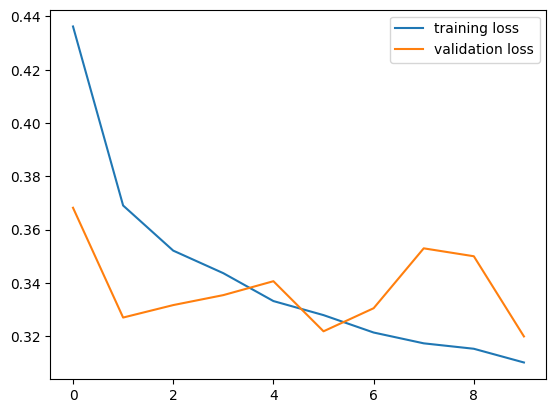

In [21]:
torch.manual_seed(1)

class NeuralNetwork(torch.nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = torch.nn.Linear(28 * 28, 128)
        self.fc2 = torch.nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.fc1(x)
        x = self.fc2(x)
        return x

net = NeuralNetwork()
optimizer = torch.optim.Adam(net.parameters())
train_loss, val_loss, model = train_model(net, optimizer)
test_model(model)
plt.plot(train_loss, label='training loss')
plt.plot(val_loss, label='validation loss')
plt.legend()
plt.show()

#### Example: Weights initialization

In PyTorch, there are several ways to initialize model weights. Proper initialization of weights is crucial for the convergence and performance of deep learning models. Here are some common methods:

Default Initialization: PyTorch initializes weights by default using a method called "Kaiming Initialization" (also known as "He Initialization" for ReLU activations). In this initialization, the weights are drawn from a normal distribution with mean 0 and variance `2/number of input units to the layer` and are designed to preserve the variance of activations in deep networks. This initialization is performed by default for linear and convolutional layers.


Using Initializers from torch.nn.init: PyTorch provides various initialization methods in the torch.nn.init module, such as Xavier initialization (xavier_uniform_, xavier_normal_), uniform initialization (uniform_), normal initialization (normal_), etc. You can directly use these initializers to initialize the weights of your layers

In [22]:
torch.manual_seed(1)

class NeuralNetwork(torch.nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = torch.nn.Linear(28 * 28, 128)
        self.fc2 = torch.nn.Linear(128, 64)
        self.fc3 = torch.nn.Linear(64, 10)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def init_weights(self):
        # Xavier initialization for fc1
        torch.nn.init.xavier_uniform_(self.fc1.weight.data)
        # Normal initialization for fc2
        torch.nn.init.normal_(self.fc2.weight.data, mean=0, std=0.01)


[1] loss: 0.363 |  Val loss: 0.255 | acc: 0.89  | Val acc: 0.89 | 
[2] loss: 0.182 |  Val loss: 0.183 | acc: 0.94  | Val acc: 0.94 | 
[3] loss: 0.139 |  Val loss: 0.125 | acc: 0.96  | Val acc: 0.96 | 
[4] loss: 0.116 |  Val loss: 0.133 | acc: 0.96  | Val acc: 0.96 | 
[5] loss: 0.101 |  Val loss: 0.147 | acc: 0.97  | Val acc: 0.97 | 
[6] loss: 0.088 |  Val loss: 0.140 | acc: 0.97  | Val acc: 0.97 | 
[7] loss: 0.082 |  Val loss: 0.126 | acc: 0.97  | Val acc: 0.97 | 
[8] loss: 0.075 |  Val loss: 0.111 | acc: 0.98  | Val acc: 0.97 | 
[9] loss: 0.069 |  Val loss: 0.152 | acc: 0.98  | Val acc: 0.97 | 
[10] loss: 0.064 |  Val loss: 0.123 | acc: 0.98  | Val acc: 0.98 | 
Testing accuracy is: 96.89%


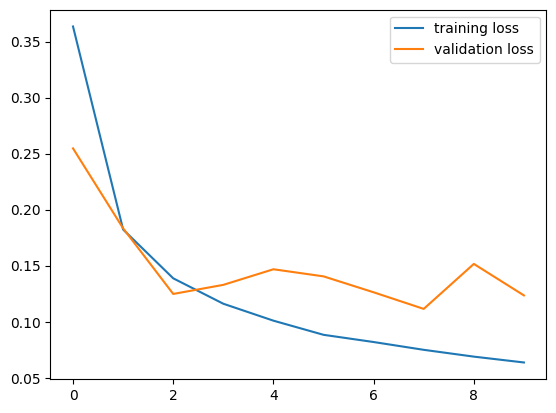

In [23]:
net = NeuralNetwork()
optimizer = torch.optim.Adam(net.parameters())
train_loss, val_loss, model = train_model(net, optimizer)
test_model(model)
plt.plot(train_loss, label='training loss')
plt.plot(val_loss, label='validation loss')
plt.legend()
plt.show()